# Segmentación de Clientes con K-Means — TechStore
### Notebook `04_segmentacion.ipynb`

Este notebook segmenta la base de clientes de **TechStore** aplicando el modelo **RFM
(Recencia, Frecuencia, Monto)** y el algoritmo **K-Means**, a partir del datamart ya
construido en el pipeline ETL (`01_datamart_etl.ipynb`).

**Flujo:**
1. Construir las variables RFM por cliente a partir de `fact_ventas`.
2. Escalar las variables (estandarización, con corrección de asimetría).
3. Determinar el número óptimo de clusters con el método del codo y el coeficiente de silueta.
4. Aplicar K-Means con el k elegido y semilla fija.
5. Perfilar cada segmento (tamaño, RFM promedio, categoría preferida, ticket).
6. Nombrar los segmentos y proponer estrategias.
7. Exportar la asignación cliente–segmento a un CSV.

**Estructura de carpetas esperada** (este notebook vive en `notebooks/`, al mismo nivel que `data/`):

```
proyecto/
├── data/
│   └── processed/    <- fact_ventas.csv, dim_cliente.csv, dim_producto.csv (salida del ETL)
└── notebooks/
    └── 04_segmentacion.ipynb   <- este archivo
```

Al ejecutar este notebook se genera `data/processed/segmentacion_clientes.csv` con la
asignación cliente → segmento.

## 1. Configuración del entorno

In [ ]:
# Celda 1 - Instalación de dependencias (descomentar si hace falta)
# !pip install pandas numpy matplotlib seaborn scikit-learn


In [1]:
# Celda 2 - Importaciones y configuración de rutas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

# Rutas relativas: este notebook vive en notebooks/, al mismo nivel que data/
PROC_DIR = '../data/processed'
RANDOM_STATE = 42

sns.set_style('whitegrid')
print('Entorno listo.')


Entorno listo.


## 2. Carga del datamart

Se reutilizan las tablas ya limpias generadas por el pipeline ETL (`01_datamart_etl.ipynb`):
`fact_ventas` (transacciones), `dim_cliente` (base completa de clientes) y `dim_producto`
(para identificar la categoría preferida de cada cliente).

In [2]:
# Celda 3 - Carga de datos del datamart
fact_ventas = pd.read_csv(f'{PROC_DIR}/fact_ventas.csv', parse_dates=['fecha'])
dim_cliente = pd.read_csv(f'{PROC_DIR}/dim_cliente.csv')
dim_producto = pd.read_csv(f'{PROC_DIR}/dim_producto.csv')

print(f'fact_ventas  : {len(fact_ventas):,} filas')
print(f'dim_cliente  : {len(dim_cliente):,} filas')
print(f'dim_producto : {len(dim_producto):,} filas')
print(f'Rango de fechas en fact_ventas: {fact_ventas["fecha"].min().date()} a {fact_ventas["fecha"].max().date()}')


fact_ventas  : 59,700 filas
dim_cliente  : 5,000 filas
dim_producto : 500 filas
Rango de fechas en fact_ventas: 2024-01-01 a 2025-12-30


## 3. Construcción de las variables RFM

Para cada cliente que registra al menos una compra en `fact_ventas` se calcula:

- **Recencia**: días transcurridos entre su última compra y el día siguiente a la fecha
  máxima registrada en el datamart (fecha de referencia del análisis).
- **Frecuencia**: número de compras **distintas** (`id_venta` único), no de líneas de venta.
- **Monto**: suma de `importe` gastado en todo el período.

Como atributos adicionales para el perfilado de negocio (no entran al modelo de clustering)
se calculan también:

- **ticket_promedio** = monto / frecuencia (gasto promedio por compra).
- **categoria_preferida** = categoría de producto en la que el cliente gastó más en total.

Los clientes de `dim_cliente` que no registran ninguna compra en el período no tienen RFM
definido y se excluyen del modelo; se conservan aparte para no perderlos del universo total
de clientes.

In [3]:
# Celda 4 - Cálculo de RFM por cliente
fecha_referencia = fact_ventas['fecha'].max() + pd.Timedelta(days=1)
print(f'Fecha de referencia para recencia: {fecha_referencia.date()}')

rfm = fact_ventas.groupby('id_cliente').agg(
    ultima_compra=('fecha', 'max'),
    frecuencia=('id_venta', 'nunique'),
    monto=('importe', 'sum'),
).reset_index()

rfm['recencia'] = (fecha_referencia - rfm['ultima_compra']).dt.days
rfm['ticket_promedio'] = (rfm['monto'] / rfm['frecuencia']).round(2)

# Categoria preferida: aquella donde el cliente acumulo mayor gasto
fact_cat = fact_ventas.merge(dim_producto[['id_producto', 'categoria']], on='id_producto', how='left')
gasto_por_categoria = fact_cat.groupby(['id_cliente', 'categoria'])['importe'].sum().reset_index()
categoria_preferida = (
    gasto_por_categoria.sort_values('importe', ascending=False)
    .drop_duplicates('id_cliente')[['id_cliente', 'categoria']]
    .rename(columns={'categoria': 'categoria_preferida'})
)
rfm = rfm.merge(categoria_preferida, on='id_cliente', how='left')

# Clientes sin compras en el periodo (no entran al modelo)
clientes_sin_compras = dim_cliente[~dim_cliente['id_cliente'].isin(rfm['id_cliente'])]

print(f'Clientes con historial de compras (entran al modelo): {len(rfm):,}')
print(f'Clientes sin compras en el periodo (excluidos del modelo): {len(clientes_sin_compras):,}')
rfm[['id_cliente', 'recencia', 'frecuencia', 'monto', 'ticket_promedio', 'categoria_preferida']].head()


Fecha de referencia para recencia: 2025-12-31
Clientes con historial de compras (entran al modelo): 3,994
Clientes sin compras en el periodo (excluidos del modelo): 1,006


,id_cliente,recencia,frecuencia,monto,ticket_promedio,categoria_preferida
0,1,431,1,386.52,386.52,Gaming
1,2,651,1,11040.52,11040.52,Celulares
2,5,3,52,84457.63,1624.19,Celulares
3,6,95,6,11951.43,1991.90,Celulares
4,7,5,16,29583.26,1848.95,Laptops


## 4. Exploración de las variables RFM

Antes de escalar, se revisan los rangos y la forma de la distribución de cada variable.
`frecuencia` y `monto` suelen tener **asimetría positiva muy fuerte** en datos de retail
(pocos clientes "ballena" concentran compras y gasto muy por encima del resto), lo que
puede hacer que K-Means (basado en distancia euclidiana) separe únicamente a esos outliers
del resto en vez de encontrar segmentos de negocio útiles.

In [4]:
# Celda 5 - Estadistica descriptiva y asimetria
print(rfm[['recencia', 'frecuencia', 'monto', 'ticket_promedio']].describe().round(2))
print()
print('=== Asimetria (skewness) ===')
for col in ['recencia', 'frecuencia', 'monto']:
    print(f'  {col:<12}: {rfm[col].skew():.2f}')


       recencia  frecuencia        monto  ticket_promedio
count   3994.00     3994.00      3994.00          3994.00
mean     184.96       14.95     56095.91          3329.84
std      192.39       54.19    311669.80         12447.72
min        1.00        1.00        20.56            20.56
25%       17.00        3.00      4788.05          1398.98
50%      101.00        6.00     12155.92          1966.49
75%      320.50       13.00     29541.30          2643.85
max      730.00     2461.00  14542489.43        358584.78

=== Asimetria (skewness) ===
  recencia    : 0.90
  frecuencia  : 28.59
  monto       : 30.51


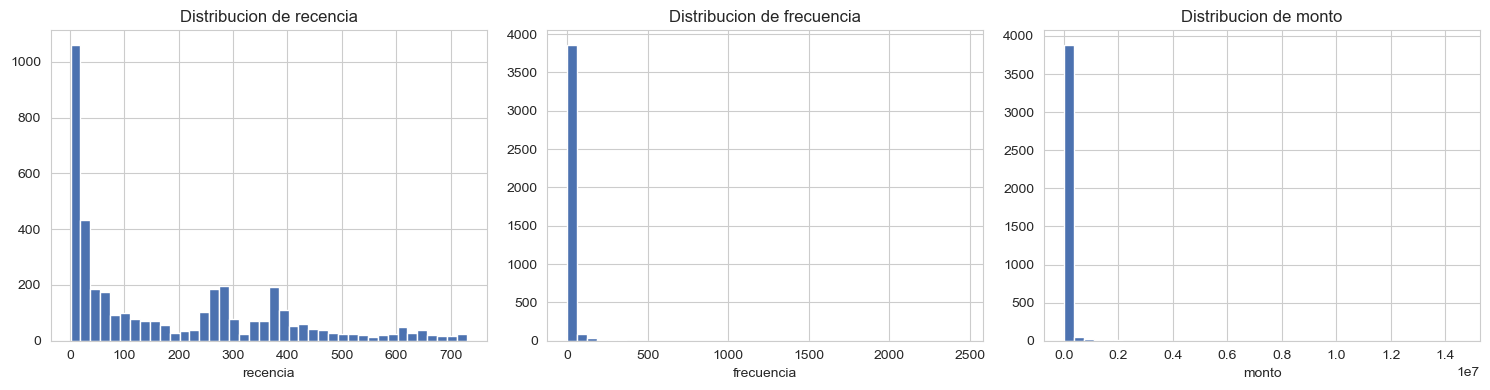

In [5]:
# Celda 6 - Visualizacion de distribuciones (antes de transformar)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['recencia', 'frecuencia', 'monto']):
    ax.hist(rfm[col], bins=40, color='#4C72B0')
    ax.set_title(f'Distribucion de {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


**Acción del estudiante:** observe las tres distribuciones. `recencia` es razonablemente
simétrica, pero `frecuencia` y `monto` están fuertemente concentradas hacia la izquierda
con una cola muy larga hacia la derecha (asimetría > 5). Para que K-Means no termine
separando únicamente a un puñado de clientes extremos del resto, se aplica una
**transformación logarítmica (`log1p`)** a `frecuencia` y `monto` antes de estandarizar.
Esta es una práctica estándar en segmentación RFM sobre datos reales de retail.

## 5. Escalado de las variables (paso indispensable)

In [6]:
# Celda 7 - Transformacion logaritmica + estandarizacion
rfm['log_frecuencia'] = np.log1p(rfm['frecuencia'])
rfm['log_monto'] = np.log1p(rfm['monto'])

print('Asimetria despues de log1p:')
print(f'  log_frecuencia: {rfm["log_frecuencia"].skew():.2f}')
print(f'  log_monto     : {rfm["log_monto"].skew():.2f}')

X = rfm[['recencia', 'log_frecuencia', 'log_monto']]

escalador = StandardScaler()
X_esc = escalador.fit_transform(X)

print(f'\nX_esc: media ~0 y desviacion ~1 por columna')
print(pd.DataFrame(X_esc, columns=X.columns).describe().round(2).loc[['mean', 'std']])


Asimetria despues de log1p:
  log_frecuencia: 0.84
  log_monto     : 0.08

X_esc: media ~0 y desviacion ~1 por columna
      recencia  log_frecuencia  log_monto
mean      -0.0            -0.0       -0.0
std        1.0             1.0        1.0


## 6. Determinar el número de clústeres

### 6.1 Método del codo

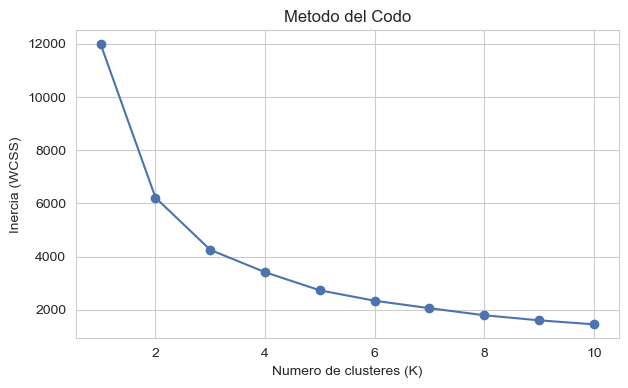

In [7]:
# Celda 8 - Metodo del codo
inercias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    km.fit(X_esc)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inercias, 'o-', color='#4C72B0')
plt.title('Metodo del Codo')
plt.xlabel('Numero de clusteres (K)')
plt.ylabel('Inercia (WCSS)')
plt.grid(True)
plt.show()


**Acción del estudiante:** observe en qué valor de K la caída de la inercia se vuelve poco significativa.

### 6.2 Coeficiente de silueta

In [8]:
# Celda 9 - Coeficiente de silueta
resultados_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(X_esc)
    sil = silhouette_score(X_esc, etiquetas)
    resultados_k.append({'k': k, 'inercia': round(km.inertia_, 1), 'silueta': round(sil, 4)})
    print(f'K={k} -> silueta promedio = {sil:.4f} | inercia = {km.inertia_:.1f}')

tabla_k = pd.DataFrame(resultados_k)


K=2 -> silueta promedio = 0.4082 | inercia = 6219.5
K=3 -> silueta promedio = 0.3681 | inercia = 4257.8
K=4 -> silueta promedio = 0.3343 | inercia = 3417.5
K=5 -> silueta promedio = 0.3660 | inercia = 2735.9
K=6 -> silueta promedio = 0.3415 | inercia = 2345.1
K=7 -> silueta promedio = 0.3435 | inercia = 2064.5
K=8 -> silueta promedio = 0.3591 | inercia = 1800.2


**Acción del estudiante:** compare el K sugerido por el codo con el que maximiza la
silueta. En este dataset, K=2 suele dar la silueta más alta porque separa de forma tosca
"clientes ballena" del resto — estadísticamente válido, pero poco útil para diseñar
campañas de marketing diferenciadas. Un K algo mayor (donde la silueta ya se estabiliza,
alrededor de K=4 o 5) suele ofrecer segmentos más accionables en términos de negocio. Ajuste
`K_ELEGIDO` en la siguiente celda según su propio análisis y justifíquelo.

## 7. Ejecutar K-Means con el K elegido

In [9]:
# Celda 10 - K elegido y justificacion
print(tabla_k)

K_ELEGIDO = 4  # <-- ajuste este valor segun su justificacion del codo + silueta

print(f'\nK elegido: {K_ELEGIDO}')
print('Justificacion: a partir de este K la inercia decrece de forma marginal (codo) y la')
print('silueta se mantiene estable, ofreciendo un balance entre cohesion estadistica y')
print('segmentos interpretables en terminos de negocio.')


   k  inercia  silueta
0  2   6219.5   0.4082
1  3   4257.8   0.3681
2  4   3417.5   0.3343
3  5   2735.9   0.3660
4  6   2345.1   0.3415
5  7   2064.5   0.3435
6  8   1800.2   0.3591

K elegido: 4
Justificacion: a partir de este K la inercia decrece de forma marginal (codo) y la
silueta se mantiene estable, ofreciendo un balance entre cohesion estadistica y
segmentos interpretables en terminos de negocio.


In [ ]:
# Celda 11 - Entrenamiento del modelo final
modelo_final = KMeans(n_clusters=K_ELEGIDO, init='k-means++', random_state=RANDOM_STATE, n_init=10)
rfm['segmento'] = modelo_final.fit_predict(X_esc)

print('Clientes por segmento:')
print(rfm['segmento'].value_counts().sort_index())


## 8. Perfilar los segmentos

Se calcula, por segmento: tamaño, promedios de RFM (en escala original, no logarítmica),
ticket promedio y categoría de producto preferida (moda).

In [ ]:
# Celda 12 - Perfilamiento de segmentos
perfil = rfm.groupby('segmento').agg(
    n_clientes=('id_cliente', 'count'),
    recencia_prom=('recencia', 'mean'),
    frecuencia_prom=('frecuencia', 'mean'),
    monto_prom=('monto', 'mean'),
    ticket_prom=('ticket_promedio', 'mean'),
).round(1)

perfil['pct_clientes'] = (perfil['n_clientes'] / perfil['n_clientes'].sum() * 100).round(1)
perfil['categoria_preferida'] = rfm.groupby('segmento')['categoria_preferida'].agg(
    lambda x: x.value_counts().idxmax()
)

perfil = perfil.sort_values('monto_prom', ascending=False)
perfil


**Acción del estudiante:** para cada segmento determine si la recencia es alta o baja,
y si la frecuencia y el monto son altos o bajos respecto al resto. Con ello valide o ajuste
el nombre comercial propuesto en la siguiente sección (por ejemplo: Campeones, Leales,
En riesgo, Nuevos, Ocasionales).

## 9. Nombrar los segmentos

Se propone un **nombre automático de partida** para cada segmento, comparando su promedio
de recencia, frecuencia y monto contra la mediana global de todos los clientes con compras.
Esta es una primera aproximación basada en reglas RFM estándar — **el criterio de negocio
final queda a juicio del estudiante**, quien puede editar el diccionario `NOMBRES_SEGMENTO`
más abajo si su interpretación difiere.

In [ ]:
# Celda 13 - Propuesta automatica de nombres de segmento
mediana_recencia = rfm['recencia'].median()
mediana_frecuencia = rfm['frecuencia'].median()
mediana_monto = rfm['monto'].median()


def sugerir_nombre(row):
    recencia_baja = row['recencia_prom'] <= mediana_recencia
    frecuencia_alta = row['frecuencia_prom'] >= mediana_frecuencia
    monto_alto = row['monto_prom'] >= mediana_monto

    if recencia_baja and frecuencia_alta and monto_alto:
        return 'Campeones'
    if recencia_baja and (frecuencia_alta or monto_alto):
        return 'Leales'
    if recencia_baja and not frecuencia_alta and not monto_alto:
        return 'Nuevos / Prometedores'
    if not recencia_baja and frecuencia_alta and monto_alto:
        return 'En riesgo (alto valor)'
    if not recencia_baja and not frecuencia_alta and not monto_alto:
        return 'Dormidos / Perdidos'
    return 'Ocasionales'


perfil['nombre_sugerido'] = perfil.apply(sugerir_nombre, axis=1)
print(perfil[['n_clientes', 'pct_clientes', 'recencia_prom', 'frecuencia_prom', 'monto_prom', 'nombre_sugerido']])

# Edite este diccionario si su interpretacion de negocio difiere del nombre sugerido
NOMBRES_SEGMENTO = perfil['nombre_sugerido'].to_dict()
rfm['nombre_segmento'] = rfm['segmento'].map(NOMBRES_SEGMENTO)
perfil['nombre_segmento'] = perfil.index.map(NOMBRES_SEGMENTO)


## 10. Visualizar los segmentos

In [ ]:
# Celda 14 - Dispersion Frecuencia vs Monto (escala log por la asimetria de los datos)
plt.figure(figsize=(8, 5))
for seg in sorted(rfm['segmento'].unique()):
    grupo = rfm[rfm['segmento'] == seg]
    nombre = NOMBRES_SEGMENTO[seg]
    plt.scatter(grupo['frecuencia'], grupo['monto'], label=f'{seg} - {nombre}', alpha=0.6)

plt.title('Segmentos de clientes: Frecuencia vs Monto')
plt.xlabel('Frecuencia de compra (numero de ordenes)')
plt.ylabel('Monto total gastado (S/.)')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Celda 15 - Dispersion Recencia vs Monto
plt.figure(figsize=(8, 5))
for seg in sorted(rfm['segmento'].unique()):
    grupo = rfm[rfm['segmento'] == seg]
    nombre = NOMBRES_SEGMENTO[seg]
    plt.scatter(grupo['recencia'], grupo['monto'], label=f'{seg} - {nombre}', alpha=0.6)

plt.title('Segmentos de clientes: Recencia vs Monto')
plt.xlabel('Recencia (dias desde la ultima compra)')
plt.ylabel('Monto total gastado (S/.)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


## 11. Estrategias gerenciales por segmento

Tabla de referencia con una acción sugerida por tipo de segmento. Ajuste el texto según su
propia interpretación del perfil obtenido.

In [ ]:
# Celda 16 - Estrategias sugeridas por segmento
ESTRATEGIAS = {
    'Campeones': 'Programa VIP, acceso anticipado a lanzamientos, atencion personalizada.',
    'Leales': 'Recompensas por fidelidad, upselling de categorias complementarias.',
    'Nuevos / Prometedores': 'Onboarding y segunda compra: cupon de bienvenida, seguimiento temprano.',
    'En riesgo (alto valor)': 'Campana de reactivacion prioritaria (alto monto en juego): descuento personalizado o contacto directo.',
    'Ocasionales': 'Recordatorios de marca y promociones estacionales para aumentar frecuencia.',
    'Dormidos / Perdidos': 'Campana de reactivacion de bajo costo o exclusion de campanas costosas.',
}

tabla_estrategias = perfil[['n_clientes', 'pct_clientes', 'recencia_prom', 'frecuencia_prom',
                             'monto_prom', 'nombre_segmento']].copy()
tabla_estrategias['accion_gerencial'] = tabla_estrategias['nombre_segmento'].map(
    lambda n: ESTRATEGIAS.get(n, 'Definir accion segun perfil.')
)
tabla_estrategias


## 12. Exportar asignación cliente–segmento

Se exporta un CSV con un registro por cliente: RFM, ticket promedio, categoría preferida,
segmento y nombre de segmento. Los clientes sin compras en el período (excluidos del
modelo) se incluyen igualmente, marcados como `Sin Actividad`, para no perder cobertura
del universo total de clientes.

In [ ]:
# Celda 17 - Exportacion del CSV cliente-segmento
os.makedirs(PROC_DIR, exist_ok=True)

columnas_salida = ['id_cliente', 'recencia', 'frecuencia', 'monto', 'ticket_promedio',
                    'categoria_preferida', 'segmento', 'nombre_segmento']
segmentacion_activos = rfm[columnas_salida].copy()

# Clientes sin compras: se agregan con metricas en cero/nulas y su propio segmento
segmentacion_inactivos = clientes_sin_compras[['id_cliente']].copy()
segmentacion_inactivos['recencia'] = np.nan
segmentacion_inactivos['frecuencia'] = 0
segmentacion_inactivos['monto'] = 0.0
segmentacion_inactivos['ticket_promedio'] = 0.0
segmentacion_inactivos['categoria_preferida'] = np.nan
segmentacion_inactivos['segmento'] = -1
segmentacion_inactivos['nombre_segmento'] = 'Sin Actividad'

segmentacion_clientes = pd.concat([segmentacion_activos, segmentacion_inactivos], ignore_index=True)
segmentacion_clientes = segmentacion_clientes.sort_values('id_cliente').reset_index(drop=True)

ruta_salida = f'{PROC_DIR}/segmentacion_clientes.csv'
segmentacion_clientes.to_csv(ruta_salida, index=False, encoding='utf-8')

print(f'Archivo exportado: {ruta_salida}')
print(f'Total de clientes exportados: {len(segmentacion_clientes):,}')
print()
print(segmentacion_clientes['nombre_segmento'].value_counts())


## 13. Resumen final

Al terminar de ejecutar este notebook, `data/processed/segmentacion_clientes.csv` contiene
la asignación cliente → segmento para toda la base de clientes:

| Columna | Descripción |
|---|---|
| `id_cliente` | Llave del cliente (coincide con `dim_cliente`) |
| `recencia` | Días desde la última compra (nulo si nunca compró) |
| `frecuencia` | Número de compras distintas en el período |
| `monto` | Gasto total acumulado, en soles |
| `ticket_promedio` | Gasto promedio por compra |
| `categoria_preferida` | Categoría de producto con mayor gasto acumulado del cliente |
| `segmento` | Número de clúster asignado por K-Means (-1 = sin compras) |
| `nombre_segmento` | Nombre de negocio asignado al segmento |

Este archivo queda listo para integrarse a un tablero de Power BI o cualquier otra
herramienta de análisis.

In [ ]:
# Celda 18 - Vista final
segmentacion_clientes.head(10)
